
TFG

Este es el codigo del tfg de Borja Jimeno

In [7]:
import sys            # módulo para interactuar con el intérprete
import os             # módulo para operaciones del sistema de archivos

import numpy as np
import math as m
import matplotlib.pyplot as plt
from scipy import special
from scipy.stats import norm
from scipy.interpolate import InterpolatedUnivariateSpline
import re

path="/home/borja/Documents/TFG/GeneraRitmo/Libs/ANAIS"
sys.path.append(path)

from funciones_ritmo_teorico import*
from funciones_ritmo_exp import*

plt.rcParams['font.size'] = 18

In [8]:
array_elements=("Na","I")
print(array_elements)

('Na', 'I')


(7.0, 10.0, 20.0, 40.0, 100.0, 200.0, 1000.0)
('Na', 'I')
Na
I
Na
I
Na
I
Na
I
Na
I
Na
I
Na
I


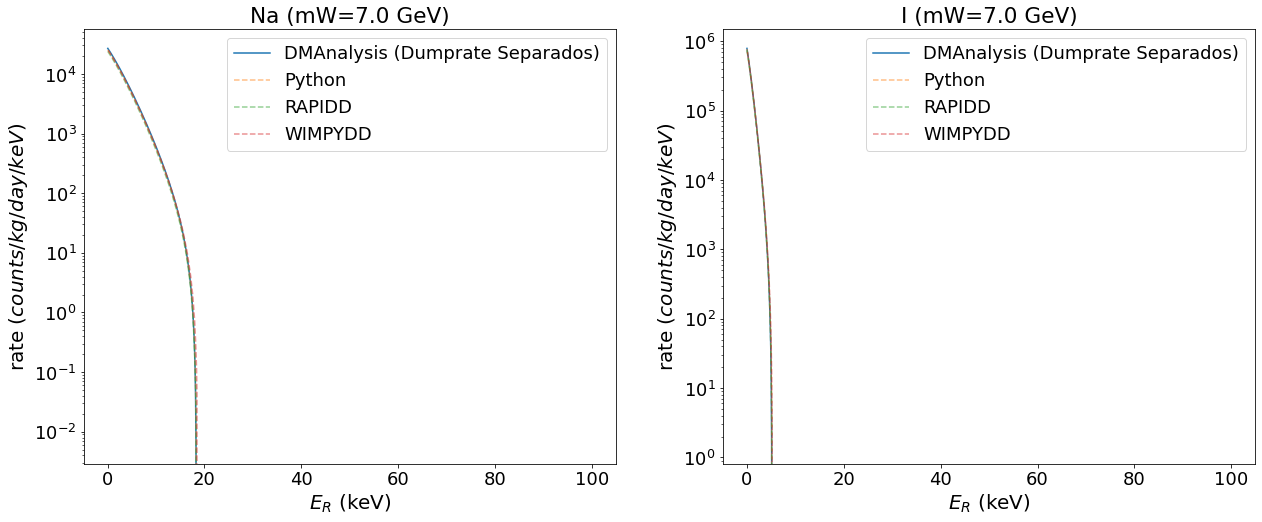

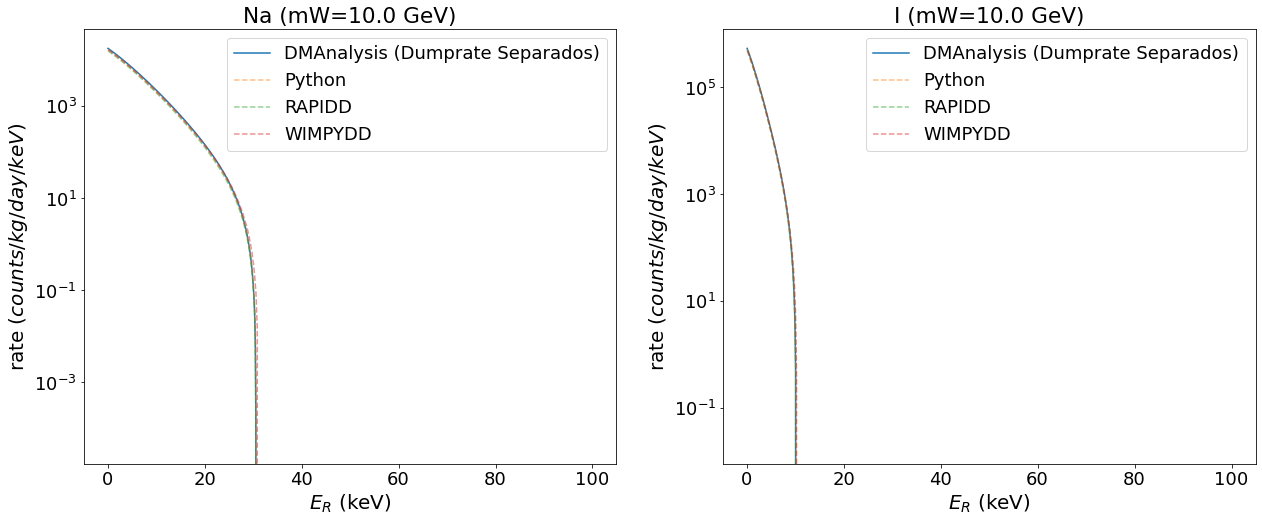

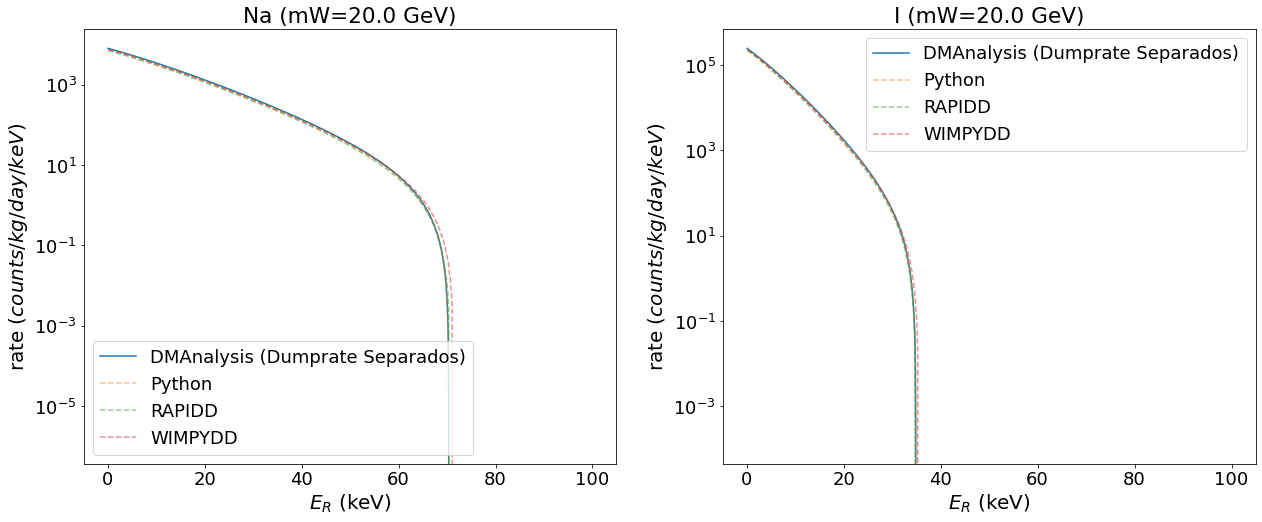

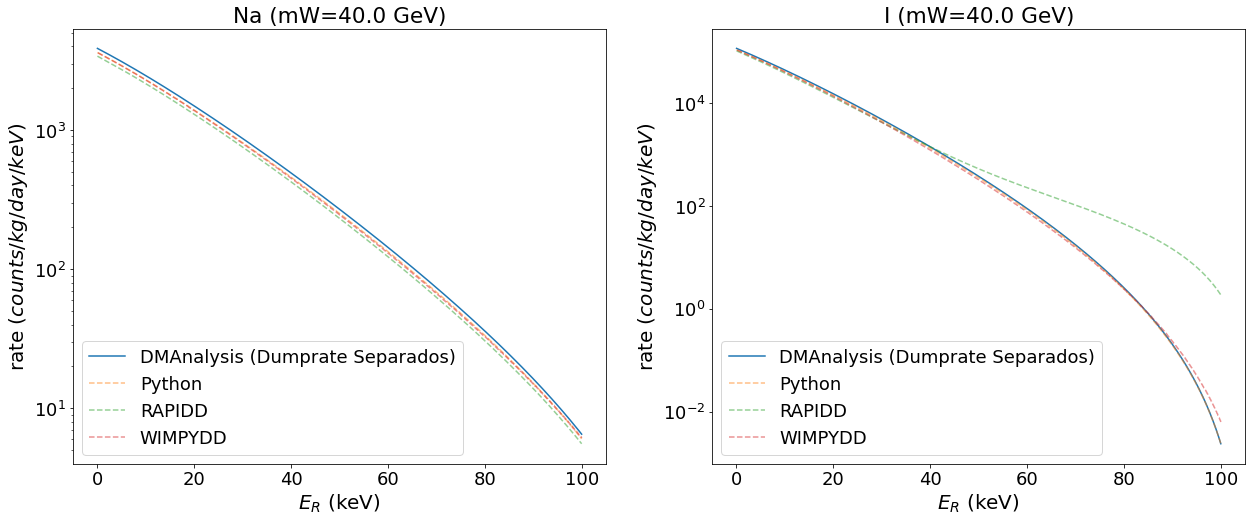

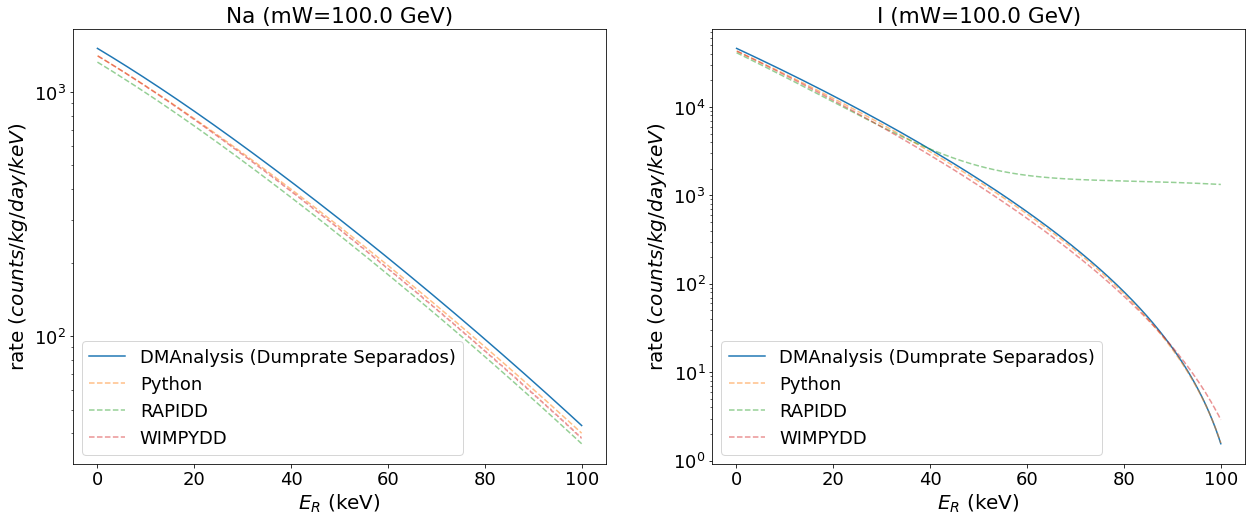

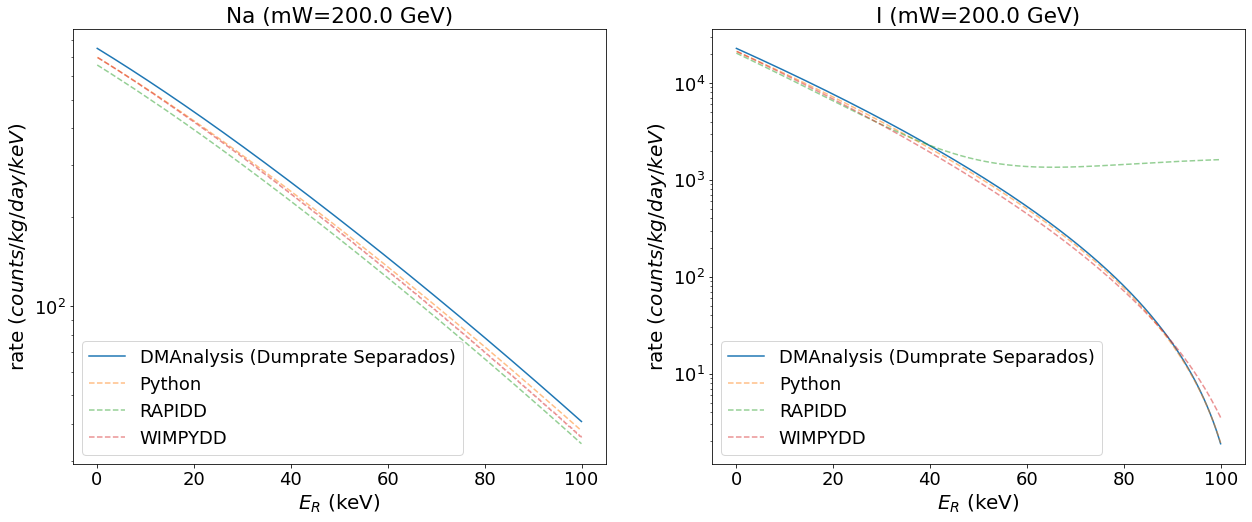

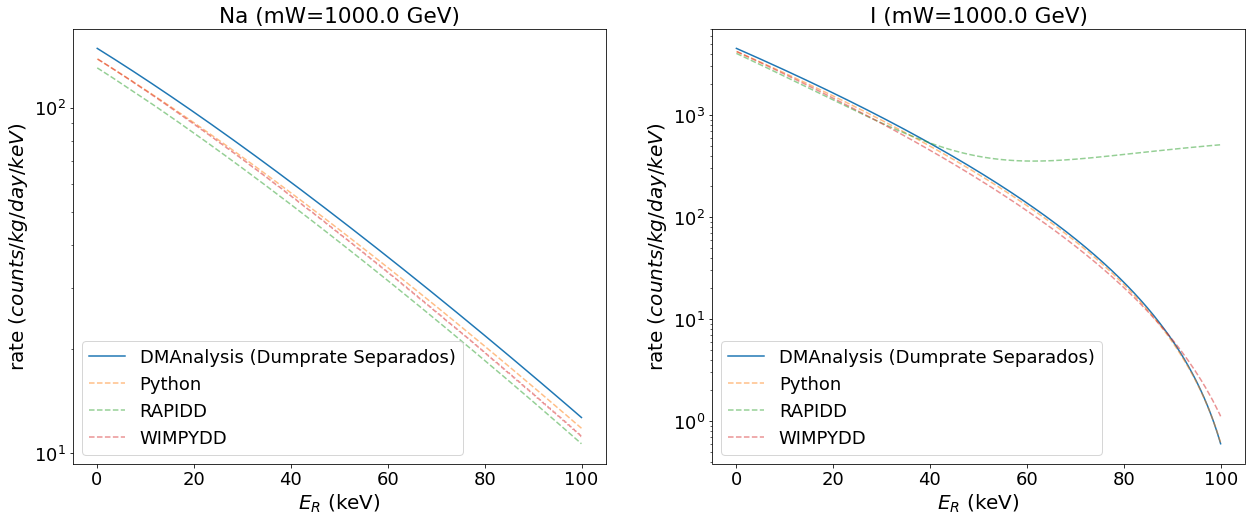

In [9]:
import uproot

array_mw=(7.0,10.0,20.0,40.0,100.0,200.0,1000.0)
print(array_mw)

array_elements=("Na","I")
print(array_elements)

timeMax=72.9 
timeMin=255.5 
timeAvg=(timeMax+timeMin)/2.

si=1e-36            
ene=np.arange(0,100,0.1)

for mW in array_mw:
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(21, 8))
        axes=(ax1, ax2)
        
        
        
        for i_element in range(len(array_elements)):
            element=array_elements[i_element]
            ax=axes[i_element]
            print(element)
        
            name2="rateDMAnalysis_SI_separados.root"
            file = uproot.open(name2)
            name="SI_rates/rate_SI_"
            name+=element
            name+="_mw"
            name+=str(np.round(mW,1))
            hist = file[name]
            bin_content = hist.values()
            DM = np.array(bin_content)
            bin_centers = hist.axis().centers()
            DM_en = np.array(bin_centers)

            

            name2="/home/borja/Documents/TFG/GeneraRitmo/Results/RAPIDD_SI_TH1D.root"
            file = uproot.open(name2)
            name="hist_"
            name+=element
            name+="_mw_"
            name+=str(np.round(mW,1))
            hist = file[name]
            bin_content = hist.values()
            rate_RA = np.array(bin_content)
            bin_centers = hist.axis().centers()
            ene_RA = np.array(bin_centers)
            
            

            name2="/home/borja/Documents/TFG/GeneraRitmo/Results/WIMPYDD_SI_TH1D.root"
            file = uproot.open(name2)
            name="hist_"
            name+=element
            name+="_mw_"
            name+=str(np.round(mW,1))
            hist = file[name]
            bin_content = hist.values()
            rate_WI = np.array(bin_content)
            bin_centers = hist.axis().centers()
            ene_WI = np.array(bin_centers)

            rate_WI=np.delete(rate_WI,0)
            ene_WI=np.delete(ene_WI,0)

            



            name2="/home/borja/Documents/TFG/GeneraRitmo/Results/ANAIS_SI_TH1D.root"
            file = uproot.open(name2)
            name="hist_"
            name+=element
            name+="_mw_"
            name+=str(np.round(mW,1))
            hist = file[name]
            bin_content = hist.values()
            rate_PY = np.array(bin_content)
            bin_centers = hist.axis().centers()
            ene_PY = np.array(bin_centers)


            ax.plot(DM_en,DM, linestyle='-',label="DMAnalysis (Dumprate Separados)", alpha=1)
            #ax.plot(DM_2_en,DM_2, linestyle='-',label="DMAnalysis (sin gausiana)", alpha=1)
            ax.plot(ene_PY,rate_PY, linestyle='--',label="Python", alpha=0.5)
            ax.plot(ene_RA,rate_RA, linestyle='--',label="RAPIDD", alpha=0.5)
            ax.plot(ene_WI,rate_WI, linestyle='--',label="WIMPYDD", alpha=0.5)
            ax.legend()

            ax.set_title(element+" (mW="+str(np.round(mW,1))+" GeV)")
            ax.set_ylabel(r'rate ($counts/kg/day/keV$)',fontsize=20)
            ax.set_xlabel(r'$E_R$ (keV)',fontsize=20)

            ax.set_yscale("log")
            #ax.set_xscale("log")





In [10]:
def rate_IP(ene,data,E):
   f_interp=InterpolatedUnivariateSpline(ene,data)
   return f_interp(E)

def rate_EP(ene,data,Eee,t,Q=1):
    E=Eee/Q
    retval=rate_IP(ene,data,E)
    retval/=Q
    return retval

def rateNaI_EP(ene_I,ene_Na,data_I,data_Na,Eee,QNa=1, QI=1):
  # convert Eee to keV_NR
  rateNa = rate_EP(ene_Na,data_Na,Eee,QNa)
  rateI = rate_EP(ene_I,data_I,Eee,QI)
 
  return (rateNa*23.+rateI*127.)/(23.+127.)

def Rate_EP_tot(ene_I,ene_Na,data_I,data_Na,Eiee,Efee):
  energy_ee = np.arange(Eiee,Efee,0.01)
  qfNa = getQFNa(energy_ee)
  qfI = getQFI(energy_ee)
  rates = np.array([
        rateNaI_EP(ene_I,ene_Na,data_I,data_Na,e,qna, qi)
        for e, qna, qi in zip(energy_ee, qfNa, qfI)
    ])
  return rates

